In [1]:
import numpy as np, pandas as pd, torch, sys
sys.path.append("../")
from ad_utils import *

device = torch.device("cuda:1")
print(torch.cuda.get_device_name(device) if torch.cuda.is_available() else "No GPU available")

train = np.load('npy/train_FD001.npy') # the data is normalized with Z-Scale
test = np.load('npy/test_FD001.npy')
print(train.shape, test.shape)

NVIDIA A30
(200, 30, 19) (188, 30, 19)


# Create test label, and randomized permutation.

In [2]:
norm_label = torch.zeros(100)
fault_label = torch.ones(88)
test_label = torch.cat([norm_label, fault_label])
perm = torch.randperm(len(test))

# Convert to images

In [3]:
train_img = build_image_tensor(train, device)
test_img = build_image_tensor(test, device)
print("Train Img min-max values: ", train_img.min(), train_img.max())
print("Test Img min-max values: ", test_img.min(), test_img.max())

print("Train img shape: ", train_img.shape)
print("Test img shape: ", test_img.shape)
torch.cuda.empty_cache()

Train Img min-max values:  tensor(0., device='cuda:1') tensor(1., device='cuda:1')
Test Img min-max values:  tensor(0., device='cuda:1') tensor(1., device='cuda:1')
Train img shape:  torch.Size([200, 19, 3, 224, 224])
Test img shape:  torch.Size([188, 19, 3, 224, 224])


# Extract Feature

In [4]:
train_feat = extract_features(train_img, device)
test_feat = extract_features(test_img, device)
print(train_feat.shape, test_feat.shape)

torch.Size([200, 77824]) torch.Size([188, 77824])


# Model initation and train

In [9]:
model = Autoencoder(n_sensors=train.shape[-1])
normalizer = FeatureNormalizer()
hist, normalizer = train_autoencoder(model=model, features_data=train_feat[:100], device=device, normalizer=normalizer, lr=0.00001, n_epochs=100)
torch.cuda.empty_cache()


  Training AE  (100 samples, 100 epochs)
Epoch    1/100  Loss: 0.160729
Epoch    2/100  Loss: 0.160666
Epoch    3/100  Loss: 0.160603
Epoch    4/100  Loss: 0.160538
Epoch    5/100  Loss: 0.160469
Epoch    6/100  Loss: 0.160393
Epoch    7/100  Loss: 0.160311
Epoch    8/100  Loss: 0.160224
Epoch    9/100  Loss: 0.160114
Epoch   10/100  Loss: 0.159995
Epoch   11/100  Loss: 0.159856
Epoch   12/100  Loss: 0.159689
Epoch   13/100  Loss: 0.159461
Epoch   14/100  Loss: 0.159135
Epoch   15/100  Loss: 0.158514
Epoch   16/100  Loss: 0.157228
Epoch   17/100  Loss: 0.154392
Epoch   18/100  Loss: 0.148234
Epoch   19/100  Loss: 0.135499
Epoch   20/100  Loss: 0.111858
Epoch   21/100  Loss: 0.079280
Epoch   22/100  Loss: 0.051352
Epoch   23/100  Loss: 0.040936
Epoch   24/100  Loss: 0.039379
Epoch   25/100  Loss: 0.038095
Epoch   26/100  Loss: 0.036525
Epoch   27/100  Loss: 0.034421
Epoch   28/100  Loss: 0.033093
Epoch   29/100  Loss: 0.032157
Epoch   30/100  Loss: 0.031903
Epoch   31/100  Loss: 0.0316

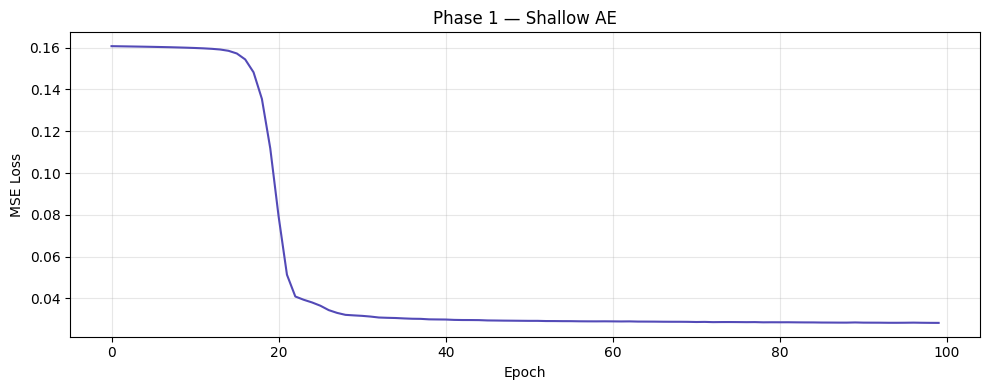

In [10]:
plot_training_curve(hist)

# Randomize test 

In [29]:
train_error = reconstruction_error(model=model, features_raw=train_feat, N_SENSORS=19, normalizer=normalizer, device=device, agg="mean")
test_error  = reconstruction_error(model=model, features_raw=test_feat, N_SENSORS=19, normalizer=normalizer, device=device, agg="mean")

[[99  1]
 [59 29]]

────────────────────────────────────────────────────
  Evaluation
────────────────────────────────────────────────────
  precision    0.9667
  recall       0.3295
  accuracy     0.6809
  f1           0.4915
  auc          0.5509


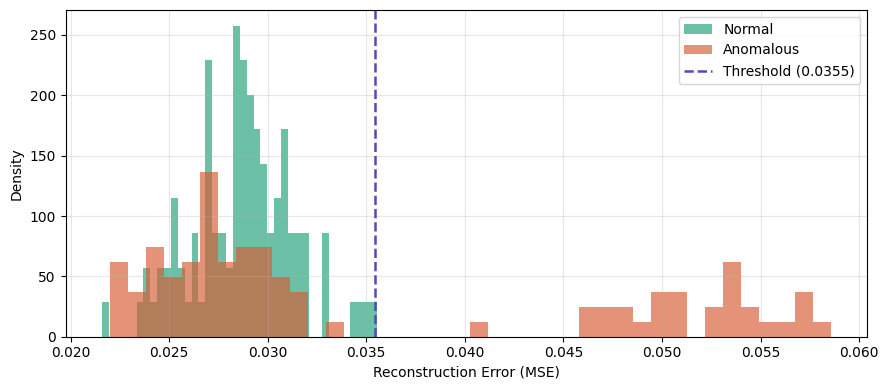

In [30]:
thresh = np.percentile(train_error, 96)
compute_metrics(errors=test_error, true_labels=test_label, threshold=thresh)
plot_error_distributions(test_error, test_label, thresh, title="")